# Linear Regression model on Housing prices: King County, USA

### Library import

In [201]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn import linear_model
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error

### Loading data

In [218]:
df_clean = pd.read_csv("../data/housing_clean.csv")
df_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,price,renovated
0,7129300520,3,1.00,1180,5650,1.0,0,0,3,7,...,98178,47.5112,-122.257,1340,5650,2014,10,13,221900.0,0
1,6414100192,3,2.25,2570,7242,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690,7639,2014,12,9,538000.0,1
2,5631500400,2,1.00,770,10000,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720,8062,2015,2,25,180000.0,0
3,2487200875,4,3.00,1960,5000,1.0,0,0,5,7,...,98136,47.5208,-122.393,1360,5000,2014,12,9,604000.0,0
4,1954400510,3,2.00,1680,8080,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800,7503,2015,2,18,510000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,3,2.50,1530,1131,3.0,0,0,3,8,...,98103,47.6993,-122.346,1530,1509,2014,5,21,360000.0,0
21609,6600060120,4,2.50,2310,5813,2.0,0,0,3,8,...,98146,47.5107,-122.362,1830,7200,2015,2,23,400000.0,0
21610,1523300141,2,0.75,1020,1350,2.0,0,0,3,7,...,98144,47.5944,-122.299,1020,2007,2014,6,23,402101.0,0
21611,291310100,3,2.50,1600,2388,2.0,0,0,3,8,...,98027,47.5345,-122.069,1410,1287,2015,1,16,400000.0,0


In [219]:
# Variable's unique values:
df_clean.nunique().sort_values(ascending=False)

id               21436
sqft_lot          9782
sqft_lot15        8689
lat               5034
price             4028
sqft_living       1038
sqft_above         946
sqft_living15      777
long               752
sqft_basement      306
yr_built           116
zipcode             70
yr_renovated        70
day                 31
bathrooms           30
bedrooms            13
month               12
grade               12
floors               6
view                 5
condition            5
waterfront           2
year                 2
renovated            2
dtype: int64

*Comments*
- Linear trends: bathroooms, sqft living, grade, sqft above, sqft living15. 
- Non linear trends: bedrooms,sqft_lot, floors,waterfront, view,
- Noisy distributions: day, month,
- Binary: renovated, year, waterfront. This may apply for a Logistic Regression.  

In [220]:
#Step 0. Creating functions for easier workflo
#Method: Linear regression

def lr_metrics(model,X_train,X_test,y_train,y_test, model_name): 
    '''
    I want to create a function that returns the basic metrics for a Linear regression: R2score and MSE.
    X1 and y1 will be the training set
    X2 and y2 will be the test set
    '''

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Creating a dictionary to include in a pandas dataframe
    metrics = {
        "Model" : [model_name, model_name],
        "Dataset" : ["Training", "Testing"],
        "R2score": [r2_score(y_train,y_train_pred),r2_score(y_test,y_test_pred)],
        "MAE":[mean_absolute_error(y_train,y_train_pred),mean_absolute_error(y_test,y_test_pred)]
        }
    #Creating the dataframe
    df = pd.DataFrame(metrics)

    return df


In [221]:
def lr_coefficients(model, feature_names):
    """
    Returns a DataFrame with feature names and their corresponding coefficients.
    
    Parameters:
    - model: trained sklearn linear model
    - feature_names: list or array of feature names (same order as training data)
    """
    coefs = model.coef_

    df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    })

    return df

In [222]:
def plot_residuals(model, X_train, X_test, y_train, y_test,model_name,save_path=None):
    """
    Plots residuals vs predicted values for train and test sets.
    """

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Residuals
    residuals_train = y_train - y_train_pred
    residuals_test = y_test - y_test_pred

    # Plot
    plt.figure(figsize=(8,6))

    plt.scatter(y_train_pred, residuals_train, alpha=0.4, label="Train")
    plt.scatter(y_test_pred, residuals_test, alpha=0.4, label="Test")

    # Reference line
    plt.axhline(0, color='red', linestyle='--')

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{model_name}")
    plt.legend()
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")


    plt.show()

## Baseline model: NO feature engineering. 

In [223]:
#Baseline model recall
features = df_clean.drop("price", axis=1)
target = df_clean["price"]
#Creating data split for model training and testing
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
#Calling the linear regression model 
Baseline_model= LinearRegression().fit(X_train, y_train)

Baseline_coefs = lr_coefficients(Baseline_model,X_train.columns)
Baseline_coefs


,feature,coefficient
0,id,-0.000001
1,bedrooms,-34472.298550
2,bathrooms,44667.878699
3,sqft_living,109.003429
4,sqft_lot,0.077380
5,floors,7538.106116
6,waterfront,562594.872294
7,view,53563.491758
8,condition,25699.929473
9,grade,94871.812684


In [224]:
Baseline_metrics = lr_metrics(Baseline_model,X_train, X_test, y_train, y_test, model_name= "Baseline")
Baseline_metrics

,Model,Dataset,R2score,MAE
0,Baseline,Training,0.700861,124711.313346
1,Baseline,Testing,0.702718,126912.390859


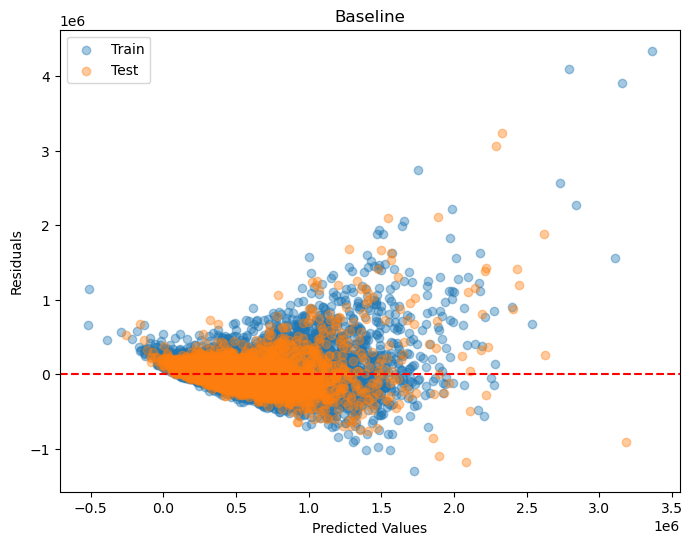

In [225]:
plot_residuals(Baseline_model, X_train, X_test, y_train, y_test,model_name= "Baseline", save_path="LR-exports/1Res.png")


*Comment*
- The results for both training and test data are very similar, so there is no significant memorization of the data by the trained model. 
- The mean square error is very high. This needs further attention for future optimizations. 
- Another aspect is that the coefficients have a high dispersion of values, from very low to very high. This means that we could (i) Standarize this data to make it comparable amongst categories and (ii)Do feature selection. 

## Step 1. All data will be standarized

The parameters for standarization can be: 
- Using the Standard Scaler function which allows to have a normalization against the standard deviation for each feature. 


In [226]:

scaler = StandardScaler()
# We scale based on the X_trained data and use the same parameters for the testing data.
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled= pd.DataFrame(X_train_scaled)
X_train_scaled.columns = X_train.columns
X_test_scaled = scaler.transform(X_test)
X_test_scaled= pd.DataFrame(X_test_scaled)
X_test_scaled.columns = X_test.columns
#Calling the linear regression model 
step1_model= LinearRegression().fit(X_train_scaled, y_train)
step1_coefs = lr_coefficients(step1_model, X_train.columns)
step1_coefs

,feature,coefficient
0,id,-4.030115e+03
1,bedrooms,-3.230950e+04
2,bathrooms,3.361191e+04
3,sqft_living,8.032416e+04
4,sqft_lot,3.161021e+03
5,floors,4.379159e+03
6,waterfront,4.786840e+04
7,view,4.102971e+04
8,condition,1.735726e+04
9,grade,1.100612e+05


In [227]:
step1_metrics= lr_metrics(step1_model, X_train_scaled,X_test_scaled, y_train, y_test, model_name="Standarized")
step1_metrics

,Model,Dataset,R2score,MAE
0,Standarized,Training,0.701635,124445.239141
1,Standarized,Testing,0.704226,126601.713232


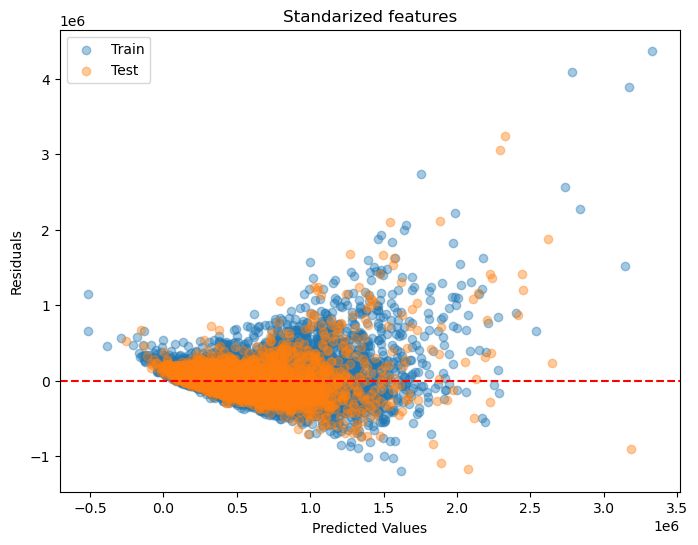

In [228]:
plot_residuals(step1_model, X_train_scaled, X_test_scaled, y_train, y_test, model_name="Standarized features", save_path="LR-Exports/2Res")


In [229]:
#Using the log_10 of the target
target_log = df_clean["price"].apply(lambda x: np.log1p(x))
target_log
#Creating data split for model training and testing
X_train_scaled, X_test_scaled, y_train_log, y_test_log = train_test_split(features, target_log, test_size=0.2, random_state=42)

# We scale based on the X_trained data and use the same parameters for the testing data.
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled= pd.DataFrame(X_train_scaled)
X_train_scaled.columns = X_train.columns
X_test_scaled = scaler.transform(X_test)
X_test_scaled= pd.DataFrame(X_test_scaled)
X_test_scaled.columns = X_test.columns

step1log_model= LinearRegression().fit(X_train_scaled, y_train_log)
step1log_metrics= lr_metrics(step1log_model, X_train_scaled,X_test_scaled, y_train_log, y_test_log, model_name="Standarized+Target_log")
step1log_metrics

,Model,Dataset,R2score,MAE
0,Standarized+Target_log,Training,0.773212,0.194193
1,Standarized+Target_log,Testing,0.773930,0.194930


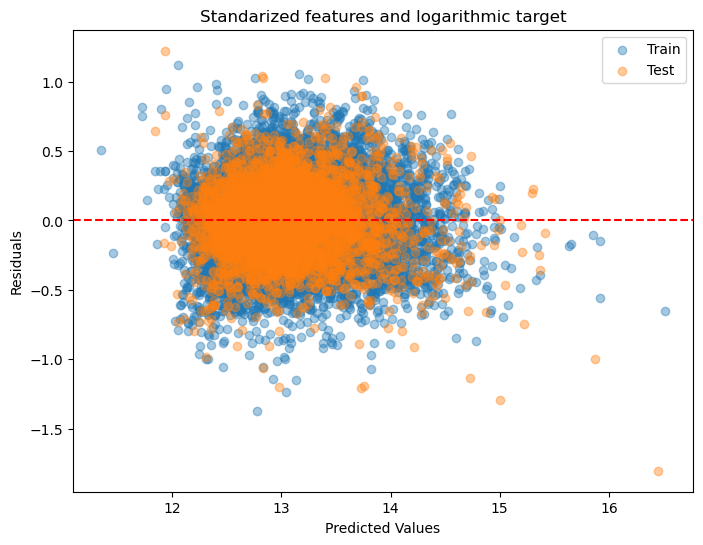

In [230]:
plot_residuals(step1log_model, X_train_scaled, X_test_scaled, y_train_log, y_test_log, model_name="Standarized features and logarithmic target", save_path="LR-Exports/3Res")


In [231]:
step1log_coefs = lr_coefficients(step1log_model, X_train_scaled.columns)
step1log_coefs.sort_values(by="coefficient",ascending=False)

,feature,coefficient
13,yr_renovated,1.989973
15,lat,0.194799
9,grade,0.181985
17,sqft_living15,0.067833
3,sqft_living,0.065975
2,bathrooms,0.055412
10,sqft_above,0.054334
7,view,0.047263
8,condition,0.042176
5,floors,0.041648


*Comments*
- After the standardization, the coefficients are now all in the range of the price. 
- Target will be switched for all future models to be in logarithmic scale. 

In [216]:
target_log = df_clean["price"].apply(lambda x: np.log1p(x))
target_log

0        12.309987
1        13.195616
2        12.100718
3        13.311331
4        13.142168
           ...    
21608    12.793862
21609    12.899222
21610    12.904461
21611    12.899222
21612    12.691584
Name: price, Length: 21613, dtype: float64

## Feature Selection

## Step 2. Ridge

In [232]:
## RidgeCV
from sklearn.linear_model import RidgeCV

# RidgeCV
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100),scoring="r2",cv=3)
ridge.fit(X_train_scaled, y_train_log)
# Check alpha
print("Best alpha:", ridge.alpha_)

Best alpha: 0.015199110829529346


In [233]:
### Ridge Regression
step2_ridge = linear_model.Ridge(alpha=0.015).fit(X_train_scaled, y_train_log) # Perform the fitting
step2_ridge_coefs = lr_coefficients(step2_ridge, X_train_scaled.columns)
step2_ridge_coefs


,feature,coefficient
0,id,0.001619
1,bedrooms,-0.011010
2,bathrooms,0.055439
3,sqft_living,0.065966
4,sqft_lot,0.015600
5,floors,0.041636
6,waterfront,0.032282
7,view,0.047253
8,condition,0.042150
9,grade,0.182026


In [234]:
step2_ridge_metrics = lr_metrics(step2_ridge,X_train_scaled,X_test_scaled,y_train_log, y_test_log, model_name="Reg:Ridge")
step2_ridge_metrics


,Model,Dataset,R2score,MAE
0,Reg:Ridge,Training,0.773211,0.194194
1,Reg:Ridge,Testing,0.773938,0.194929


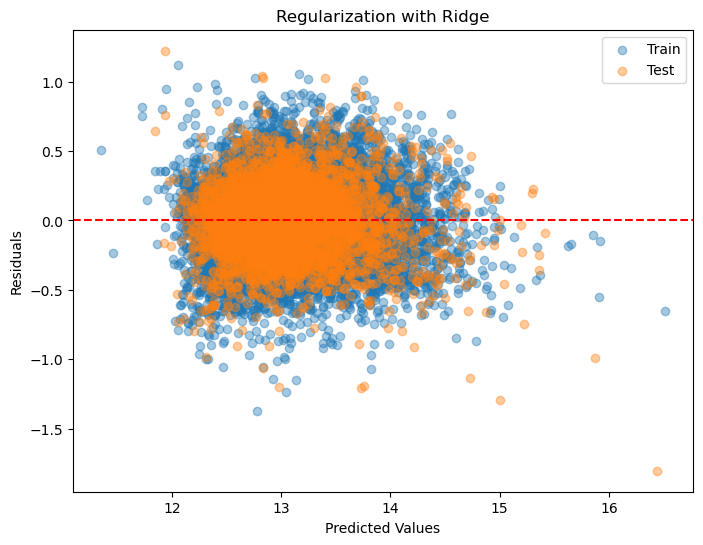

In [236]:
plot_residuals(step2_ridge, X_train_scaled, X_test_scaled, y_train_log, y_test_log, model_name = "Regularization with Ridge", save_path="LR-Exports/4Res.png")


## Step 3. Lasso

In [238]:
##Lasso CV
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5, random_state=10).fit(X_train_scaled,y_train_log)
# Best alpha found
print("Best alpha:", lasso.alpha_)

Best alpha: 0.000642204404460008


In [270]:
##Lasso regression: 
step3_lasso = linear_model.Lasso(alpha=0.00064, max_iter=100).fit(X_train_scaled, y_train_log) # Perform the fitting
step3_lasso_coefs = lr_coefficients(step3_lasso, X_train_scaled.columns)
step3_lasso_coefs["coefficient"]=step3_lasso_coefs["coefficient"].apply(lambda x: np.abs(x))
step3_lasso_coefs= step3_lasso_coefs.sort_values(by="coefficient",ascending=True)
step3_lasso_coefs


c:\Users\nicol\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.197e+01, tolerance: 4.762e-01
  model = cd_fast.enet_coordinate_descent(


,feature,coefficient
22,renovated,0.000000
0,id,0.001007
11,sqft_basement,0.003026
18,sqft_lot15,0.003103
21,day,0.003220
20,month,0.004162
1,bedrooms,0.009969
4,sqft_lot,0.013144
13,yr_renovated,0.014513
16,long,0.017520


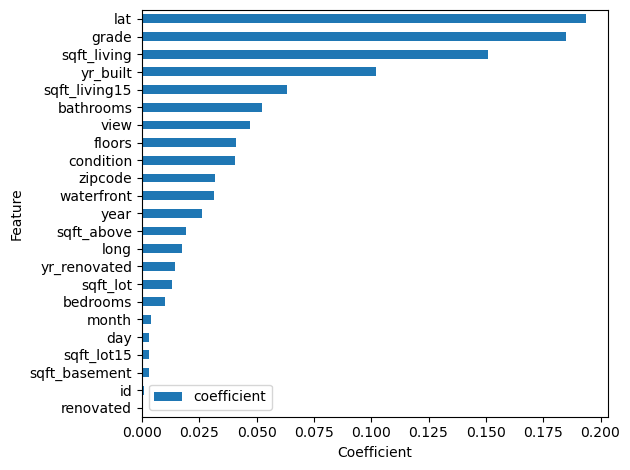

In [273]:
step3_lasso_coefs.plot.barh("feature","coefficient")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
filepath_lasso1 = Path("LR-Exports/Lasso_coef1.png")
plt.savefig(filepath_lasso1)

In [241]:
step3_lasso_metrics = lr_metrics(step3_lasso, X_train_scaled,X_test_scaled,y_train_log, y_test_log, "Reg:Lasso")
step3_lasso_metrics


,Model,Dataset,R2score,MAE
0,Reg:Lasso,Training,0.772267,0.194517
1,Reg:Lasso,Testing,0.773065,0.195197


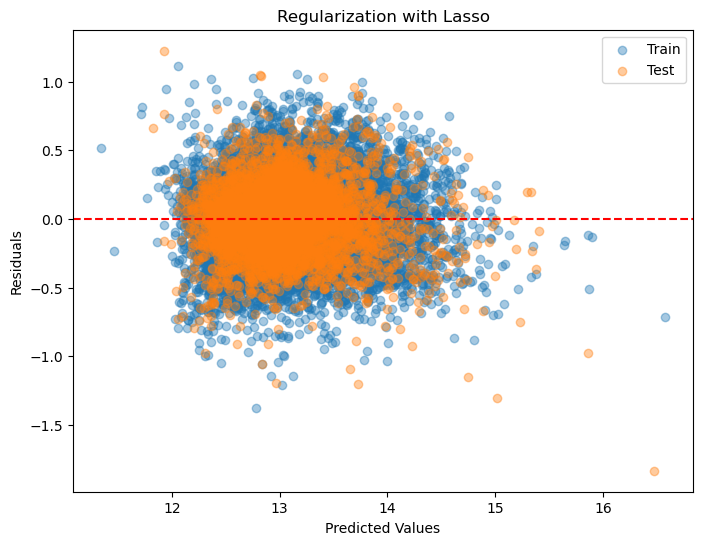

In [242]:
plot_residuals(step3_lasso, X_train_scaled, X_test_scaled, y_train_log, y_test_log, model_name = "Regularization with Lasso", save_path="LR-Exports/5Res.png")

**Watching out for alpha** 
The modifications of the alpha and number of iterations changed significantly the values of the obtained coefficients. This makes me think that I need to optimize this parameters before continuing. 

In [284]:
#What if take only those features?
X_train_scaled_lasso = X_train_scaled[["lat","grade","sqft_living","yr_built","sqft_living15","bathrooms"]]
X_test_scaled_lasso = X_test_scaled[["lat","grade","sqft_living","yr_built","sqft_living15","bathrooms"]]
step3_1_lasso = linear_model.Lasso(alpha=0.00064, max_iter=100).fit(X_train_scaled_lasso, y_train_log) # Perform the fitting
step3_1_lasso_metrics = lr_metrics(step3_1_lasso, X_train_scaled_lasso,X_test_scaled_lasso,y_train_log, y_test_log, "Reg:Lasso")
step3_1_lasso_metrics

,Model,Dataset,R2score,MAE
0,Reg:Lasso,Training,0.744458,0.205056
1,Reg:Lasso,Testing,0.742348,0.207449


In [86]:
#Now that the coefficients are more balances I will move to feature selection based on the coefficients found by the Lasso and ridge. 

reg_df_coef = pd.merge(step2_ridge_coefs,step3_lasso_coefs, left_on ="feature", right_on= "feature")
reg_df_coef.columns =["Features","Ridge","Lasso"]
reg_df_coef["Ridge-abs"] = reg_df_coef["Ridge"].apply(lambda x: np.abs(x))
reg_df_coef["Lasso-abs"] = reg_df_coef["Lasso"].apply(lambda x: np.abs(x))
reg_df_coef.sort_values(by="Lasso-abs", ascending=False)


,Features,Ridge,Lasso,Ridge-abs,Lasso-abs
15,lat,0.194793,0.193690,0.194793,0.193690
9,grade,0.182026,0.185111,0.182026,0.185111
3,sqft_living,0.065966,0.150765,0.065966,0.150765
12,yr_built,-0.102906,-0.101873,0.102906,0.101873
17,sqft_living15,0.067811,0.063171,0.067811,0.063171
2,bathrooms,0.055439,0.052171,0.055439,0.052171
7,view,0.047253,0.046947,0.047253,0.046947
5,floors,0.041636,0.041042,0.041636,0.041042
8,condition,0.042150,0.040398,0.042150,0.040398
14,zipcode,-0.033543,-0.031694,0.033543,0.031694


Features with higher importance seem to be: 
1. sqft_living, sqft_living15
2. grade 
3. only the latitude seems to be strong, but not so the longitude. however, both should give us information about the location. 
4. view
It's all about location, quality and size. I'll keep this in mind for the Feature selection and engineering.

In [285]:
## Summary
from pathlib import Path
Results1 = pd.concat([Baseline_metrics,step1_metrics,step1log_metrics, step2_ridge_metrics, step3_lasso_metrics,step3_1_lasso_metrics], axis=0)
Results1.insert(0,"model_index",[0,0,1,1,2,2,3,3,4,4,5,5])
filepath = Path("LR-Exports/LR-Baseline optimization.csv")
Results1.to_csv(filepath,header=True, index="Model")


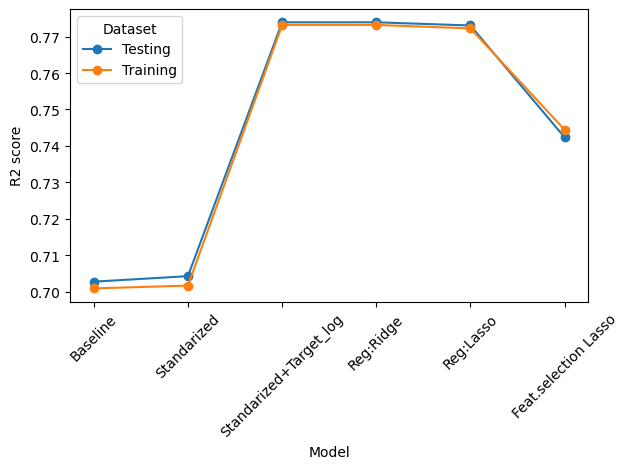

In [286]:
Results1_pivot = Results1.pivot(
    index="model_index",
    columns="Dataset",
    values="R2score"
)
Results1_pivot
g= Results1_pivot.plot(marker='o')
plt.xlabel("Model")
plt.ylabel("R2 score")
g.set_xticks(range(len(Results1_pivot.index)))
g.set_xticklabels(["Baseline", "Standarized", "Standarized+Target_log", "Reg:Ridge","Reg:Lasso","Feat.selection Lasso"], rotation =45)
filepath1 = Path("LR-Exports/LR-Baseline_opt_r2.png")
plt.tight_layout()
plt.savefig(filepath1)
plt.show()

## Feature engineering:

### Removing features

1. Removing binary variables like: 
 
- waterfront
- year of the sale 
- renovated
2. Based on coefficients: 
- day
- id 
- month

In [88]:
df_clean.nunique()

id               21436
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
year                 2
month               12
day                 31
price             4028
renovated            2
dtype: int64

- Eliminating binary variables
- Eliminating low coefficient
- eliminating sqft basement and sqft above because the sum of them is sqft living

In [305]:
feature_select = df_clean.drop(["waterfront","year","renovated","price", "id", "day","month","sqft_above", "sqft_basement","zipcode"], axis=1)
feature_select

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,3,7,1955,0,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,3,7,1951,1991,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,3,6,1933,0,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,5,7,1965,0,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,3,8,1987,0,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,3,8,2009,0,47.6993,-122.346,1530,1509
21609,4,2.50,2310,5813,2.0,0,3,8,2014,0,47.5107,-122.362,1830,7200
21610,2,0.75,1020,1350,2.0,0,3,7,2009,0,47.5944,-122.299,1020,2007
21611,3,2.50,1600,2388,2.0,0,3,8,2004,0,47.5345,-122.069,1410,1287


In [306]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(feature_select, target_log, test_size=0.2, random_state=42)
X_train1_scaled = scaler.fit_transform(X_train1)
X_train1_scaled= pd.DataFrame(X_train1_scaled)
X_train1_scaled.columns = X_train1.columns
X_test1_scaled = scaler.transform(X_test1)
X_test1_scaled= pd.DataFrame(X_test1_scaled)
X_test1_scaled.columns = X_test1.columns
rawdrop_model = LinearRegression().fit(X_train1_scaled,y_train1)
rawdrop_metrics = lr_metrics(rawdrop_model, X_train1_scaled,X_test1_scaled,y_train1, y_test1, "Raw drop")
rawdrop_metrics

,Model,Dataset,R2score,MAE
0,Raw drop,Training,0.764564,0.196954
1,Raw drop,Testing,0.764326,0.198094


In [307]:
# Encoding the zipcode by using lat and long, which may sound like a Kmeans problem. 
house_location = feature_select[["lat","long"]]


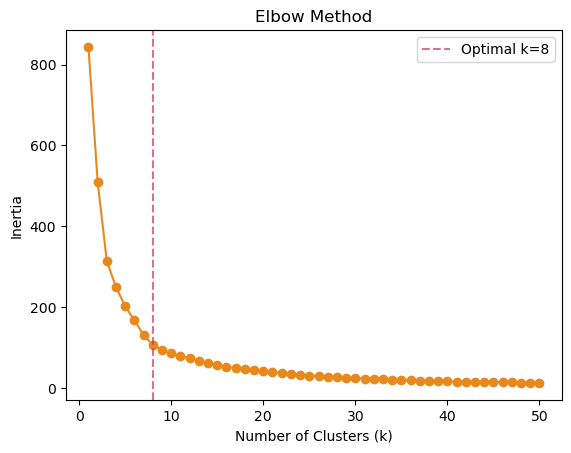

np.int64(8)

In [308]:
from sklearn.cluster import KMeans

def find_elbow(data, max_k=10):
    from kneed import KneeLocator
    inertia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        inertia.append(kmeans.inertia_)
    # Detect the elbow using KneeLocator
    knee_locator = KneeLocator(range(1, max_k + 1), inertia, curve="convex", direction="decreasing")
    optimal_k = knee_locator.knee
    # Plot inertia for visualization
    plt.plot(range(1, max_k + 1), inertia, marker='o', color="#e8891d")
    plt.axvline(x=optimal_k, color='#b35a', linestyle='--', label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.legend()
    plt.show()
    return optimal_k

find_elbow(house_location,max_k=50)

In [309]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(house_location)
# Silhouette Score
kmeans_score = silhouette_score(house_location, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.3f}")


K-Means Silhouette Score: 0.431


In [311]:
house_location["labels"] = kmeans_labels
house_location

C:\Users\nicol\AppData\Local\Temp\ipykernel_22076\3298810725.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_location["labels"] = kmeans_labels


,lat,long,labels
0,47.5112,-122.257,3
1,47.7210,-122.319,0
2,47.7379,-122.233,7
3,47.5208,-122.393,3
4,47.6168,-122.045,5
...,...,...,...
21608,47.6993,-122.346,0
21609,47.5107,-122.362,3
21610,47.5944,-122.299,3
21611,47.5345,-122.069,5


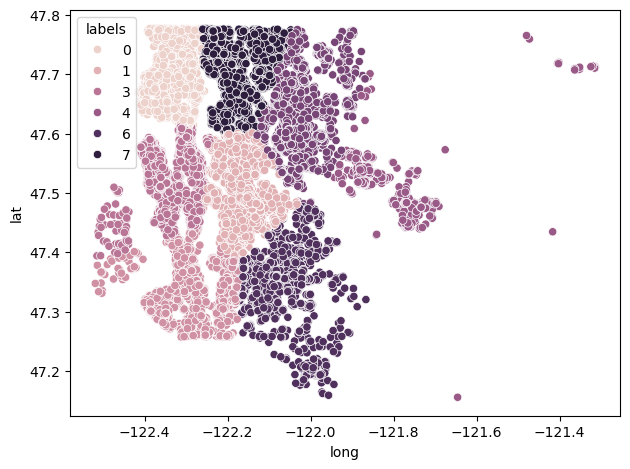

In [312]:
sns.scatterplot(x="long", 
                y="lat",
                data=house_location,
                hue="labels", 
                )
filepath1 = Path("LR-Exports/Kmeans-latlong.png")
plt.tight_layout()
plt.savefig(filepath1)

plt.show()


In [313]:
#Creating copy to avoid data loss
feature_select3 = feature_select.copy()
feature_select3["location_cluster"] = house_location["labels"]
feature_select3

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,location_cluster
0,3,1.00,1180,5650,1.0,0,3,7,1955,0,47.5112,-122.257,1340,5650,3
1,3,2.25,2570,7242,2.0,0,3,7,1951,1991,47.7210,-122.319,1690,7639,0
2,2,1.00,770,10000,1.0,0,3,6,1933,0,47.7379,-122.233,2720,8062,7
3,4,3.00,1960,5000,1.0,0,5,7,1965,0,47.5208,-122.393,1360,5000,3
4,3,2.00,1680,8080,1.0,0,3,8,1987,0,47.6168,-122.045,1800,7503,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,3,8,2009,0,47.6993,-122.346,1530,1509,0
21609,4,2.50,2310,5813,2.0,0,3,8,2014,0,47.5107,-122.362,1830,7200,3
21610,2,0.75,1020,1350,2.0,0,3,7,2009,0,47.5944,-122.299,1020,2007,3
21611,3,2.50,1600,2388,2.0,0,3,8,2004,0,47.5345,-122.069,1410,1287,5


In [314]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(feature_select3, target_log, test_size=0.2, random_state=42)
X_train3_scaled = scaler.fit_transform(X_train3)
X_train3_scaled= pd.DataFrame(X_train3_scaled)
X_train3_scaled.columns = X_train3.columns
X_test3_scaled = scaler.transform(X_test3)
X_test3_scaled= pd.DataFrame(X_test3_scaled)
X_test3_scaled.columns = X_test3.columns
location_model = LinearRegression().fit(X_train3_scaled,y_train3)
location_metrics = lr_metrics(location_model, X_train3_scaled,X_test3_scaled,y_train3, y_test3, "Cluster locations")
location_metrics

,Model,Dataset,R2score,MAE
0,Cluster locations,Training,0.764599,0.196856
1,Cluster locations,Testing,0.764266,0.198045


In [315]:
## Location median
feature_select4 = feature_select.copy()
lat_median = feature_select4["lat"].median()
long_median = feature_select4["long"].median()

feature_select4["distance_center"] = np.sqrt(feature_select4["lat"].apply(lambda x: (x-lat_median)**2)+feature_select4["long"].apply(lambda x: (x-long_median)**2))
feature_select4

X_train4, X_test4, y_train4, y_test4 = train_test_split(feature_select4, target_log, test_size=0.2, random_state=42)
X_train4_scaled = scaler.fit_transform(X_train4)
X_train4_scaled= pd.DataFrame(X_train4_scaled)
X_train4_scaled.columns = X_train4.columns
X_test4_scaled = scaler.transform(X_test4)
X_test4_scaled= pd.DataFrame(X_test4_scaled)
X_test4_scaled.columns = X_test4.columns
distcenter_model = LinearRegression().fit(X_train4_scaled,y_train4)
distcenter_metrics = lr_metrics(distcenter_model, X_train4_scaled,X_test4_scaled,y_train4, y_test4, "Distant center")
distcenter_metrics

,Model,Dataset,R2score,MAE
0,Distant center,Training,0.773929,0.193770
1,Distant center,Testing,0.776136,0.194216


In [317]:
#Adding coordinates as lat**2, long**2 and latxlong for spatial training of the data
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
coords = poly.fit_transform(feature_select[["lat", "long"]])
coords = pd.DataFrame(coords)
coords.columns = ["lat","long","lat^2","latxlong","long^2"]
feature_select5 = feature_select.copy()
feature_select5["lat^2"] = coords["lat^2"]
feature_select5["long^2"] = coords["long^2"]
feature_select5["latxlong"] = coords["latxlong"]
X_train5, X_test5, y_train5, y_test5 = train_test_split(feature_select5, target_log, test_size=0.2, random_state=42)
X_train5_scaled = scaler.fit_transform(X_train5)
X_train5_scaled= pd.DataFrame(X_train5_scaled)
X_train5_scaled.columns = X_train5.columns
X_test5_scaled = scaler.transform(X_test5)
X_test5_scaled= pd.DataFrame(X_test5_scaled)
X_test5_scaled.columns = X_test5.columns
poly_model = LinearRegression().fit(X_train5_scaled,y_train5)
poly_metrics = lr_metrics(poly_model, X_train5_scaled,X_test5_scaled,y_train5, y_test5, "Polynomial coefficients")
poly_metrics

,Model,Dataset,R2score,MAE
0,Polynomial coefficients,Training,0.786596,0.185702
1,Polynomial coefficients,Testing,0.787458,0.186948


Treating locations as non linear worked best!

In [321]:
## Summary
from pathlib import Path
Results2 = pd.concat([rawdrop_metrics,location_metrics,distcenter_metrics, poly_metrics], axis=0)
Results2.insert(0,"model_index",[0,0,1,1,2,2,3,3])
filepath = Path("LR-Exports/Location optimization.csv")
Results1.to_csv(filepath,header=True, index="Model")
Results2

,model_index,Model,Dataset,R2score,MAE
0,0,Raw drop,Training,0.764564,0.196954
1,0,Raw drop,Testing,0.764326,0.198094
0,1,Cluster locations,Training,0.764599,0.196856
1,1,Cluster locations,Testing,0.764266,0.198045
0,2,Distant center,Training,0.773929,0.193770
1,2,Distant center,Testing,0.776136,0.194216
0,3,Polynomial coefficients,Training,0.786596,0.185702
1,3,Polynomial coefficients,Testing,0.787458,0.186948


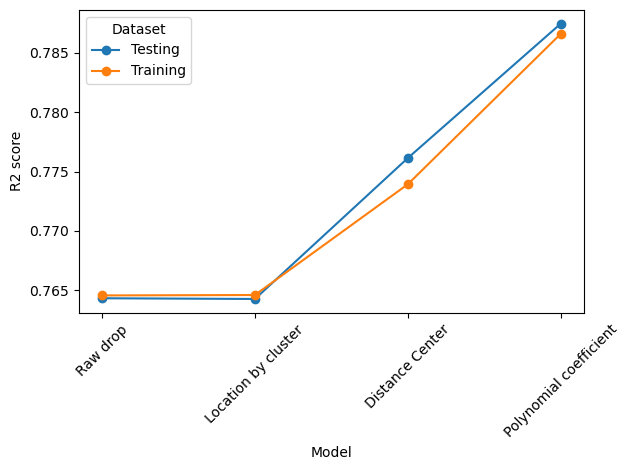

In [323]:
Results2_pivot = Results2.pivot(
    index="model_index",
    columns="Dataset",
    values="R2score"
)

g= Results2_pivot.plot(marker='o')
plt.xlabel("Model")
plt.ylabel("R2 score")
g.set_xticks(range(len(Results2_pivot.index)))
g.set_xticklabels(["Raw drop", "Location by cluster", "Distance Center", "Polynomial coefficient"], rotation =45)
filepath2 = Path("LR-Exports/LR-Location_opt_r2.png")
plt.tight_layout()
plt.savefig(filepath2)
plt.show()

In [324]:
#Living average over years
feature_select6=feature_select5.copy()
feature_select6["mean_sqft_living"] = (feature_select6["sqft_living"]+feature_select6["sqft_living15"])/2
feature_select6 = feature_select6.drop(["sqft_living","sqft_living15"],axis=1)
#Rescaling other sqft variables 
feature_select6["log_sqft_lot"] = feature_select6["sqft_lot"].apply(lambda x: np.log1p(x))
feature_select6["log_sqft_lot15"] = feature_select6["sqft_lot15"].apply(lambda x: np.log1p(x))
feature_select6["log_mean_sqft_living"] = feature_select6["mean_sqft_living"].apply(lambda x: np.log1p(x))
feature_select6= feature_select6.drop(["sqft_lot15","sqft_lot","mean_sqft_living"],axis=1)

feature_select6


,bedrooms,bathrooms,floors,view,condition,grade,yr_built,yr_renovated,lat,long,lat^2,long^2,latxlong,log_sqft_lot,log_sqft_lot15,log_mean_sqft_living
0,3,1.00,1.0,0,3,7,1955,0,47.5112,-122.257,2257.314125,14946.774049,-5808.576778,8.639588,8.639588,7.139660
1,3,2.25,2.0,0,3,7,1951,1991,47.7210,-122.319,2277.293841,14961.937761,-5837.184999,8.887791,8.941153,7.664347
2,2,1.00,1.0,0,3,6,1933,0,47.7379,-122.233,2278.907096,14940.906289,-5835.146731,9.210440,8.995041,7.465083
3,4,3.00,1.0,0,5,7,1965,0,47.5208,-122.393,2258.226433,14980.046449,-5816.213274,8.517393,8.517393,7.415175
4,3,2.00,1.0,0,3,8,1987,0,47.6168,-122.045,2267.359642,14894.982025,-5811.392356,8.997271,8.923191,7.462215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,3.0,0,3,8,2009,0,47.6993,-122.346,2275.223220,14968.543716,-5835.818558,7.031741,7.319865,7.333676
21609,4,2.50,2.0,0,3,8,2014,0,47.5107,-122.362,2257.266614,14972.459044,-5813.504273,8.668024,8.881975,7.635787
21610,2,0.75,2.0,0,3,7,2009,0,47.5944,-122.299,2265.226911,14957.045401,-5820.747526,7.208600,7.604894,6.928538
21611,3,2.50,2.0,0,3,8,2004,0,47.5345,-122.069,2259.528690,14900.840761,-5802.488881,7.778630,7.160846,7.317212


In [326]:
# Rescaling data: 

#Creating data split for model training and testing
X_train6, X_test6, y_train6, y_test6 = train_test_split(feature_select6, target_log, test_size=0.2, random_state=42)

# We scale based on the X_trained data and use the same parameters for the testing data.
X_train6_scaled = scaler.fit_transform(X_train6)
X_train6_scaled= pd.DataFrame(X_train6_scaled)
X_train6_scaled.columns = X_train6.columns
X_test6_scaled = scaler.transform(X_test6)
X_test6_scaled= pd.DataFrame(X_test6_scaled)
X_test6_scaled.columns = X_test6.columns
#Calling a Linear regression: 
model6 = LinearRegression().fit(X_train6_scaled, y_train6) # Perform the fitting
model6_coefs = lr_coefficients(model6, X_train6_scaled.columns)
model6_coefs["Coeff-abs"] = model6_coefs["coefficient"].apply(lambda x: np.abs(x))
model6_coefs.sort_values(by="Coeff-abs", ascending=False)

,feature,coefficient,Coeff-abs
10,lat^2,-50.452319,50.452319
12,latxlong,-50.094177,50.094177
9,long,28.369722,28.369722
11,long^2,10.795872,10.795872
8,lat,6.089881,6.089881
15,log_mean_sqft_living,0.200938,0.200938
5,grade,0.181444,0.181444
6,yr_built,-0.074942,0.074942
3,view,0.053918,0.053918
1,bathrooms,0.051083,0.051083


In [328]:
model6_metrics = lr_metrics(model6, X_train6_scaled, X_test6_scaled, y_train6, y_test6, "Sqft linearization")
model6_metrics


,Model,Dataset,R2score,MAE
0,Sqft linearization,Training,0.789929,0.184487
1,Sqft linearization,Testing,0.792540,0.185590


In [329]:
from sklearn.linear_model import RidgeCV

# RidgeCV
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100),scoring="r2",cv=3)
ridge.fit(X_train6_scaled, y_train6)
# Check alpha
print("Best alpha:", ridge.alpha_)

Best alpha: 0.0001


In [330]:
### Ridge Regression
model6_ridge = linear_model.Ridge(alpha=0.0001).fit(X_train6_scaled, y_train6) # Perform the fitting
model6_ridge_coefs = lr_coefficients(model6_ridge, X_train6_scaled.columns)
model6_ridge_coefs

,feature,coefficient
0,bedrooms,-0.017264
1,bathrooms,0.051143
2,floors,0.022838
3,view,0.053986
4,condition,0.043553
5,grade,0.181497
6,yr_built,-0.075164
7,yr_renovated,0.017889
8,lat,6.275143
9,long,27.885481


In [333]:
model6_ridge_metrics = lr_metrics(model6_ridge, X_train6_scaled, X_test6_scaled, y_train6, y_test6, "Ridge+Sqft linearization")
model6_ridge_metrics

,Model,Dataset,R2score,MAE
0,Ridge+Sqft linearization,Training,0.789928,0.184485
1,Ridge+Sqft linearization,Testing,0.792536,0.185588


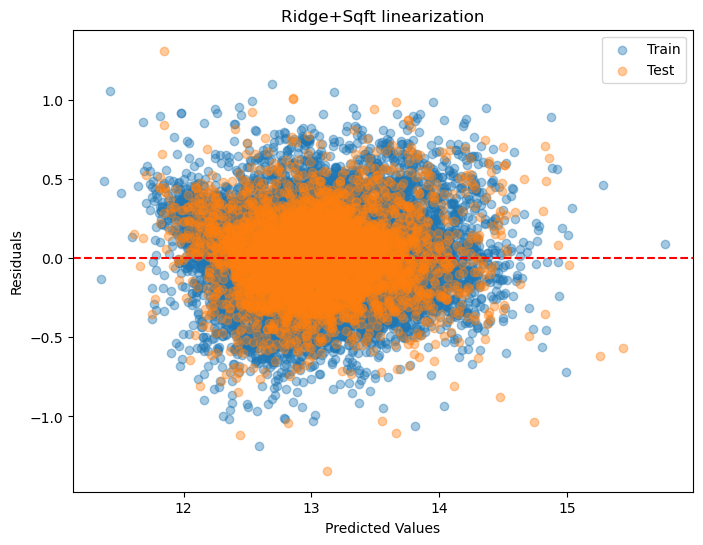

In [335]:
plot_residuals(model6_ridge, X_train6_scaled, X_test6_scaled, y_train6, y_test6, model_name="Ridge+Sqft linearization", save_path="LR-Exports/ResRidge_Sqftlinearization.png")

In [338]:
# Zipcode? 
# Encode zipcode
feature_select7 = feature_select6.copy()
feature_select7["zipcode"] = df_clean["zipcode"]

feature_select7 = pd.get_dummies(feature_select7, columns=["zipcode"], drop_first=True)
feature_select7

#Creating data split for model training and testing
X_train7, X_test7, y_train7, y_test7 = train_test_split(feature_select7, target_log, test_size=0.2, random_state=42)

# We scale based on the X_trained data and use the same parameters for the testing data.
X_train7_scaled = scaler.fit_transform(X_train7)
X_train7_scaled= pd.DataFrame(X_train7_scaled)
X_train7_scaled.columns = X_train7.columns
X_test7_scaled = scaler.transform(X_test7)
X_test7_scaled= pd.DataFrame(X_test7_scaled)
X_test7_scaled.columns = X_test7.columns
#Calling a Linear regression: 
model7 = LinearRegression().fit(X_train7_scaled, y_train7) # Perform the fitting
model7_coefs = lr_coefficients(model7, X_train7_scaled.columns)
model7_coefs["Coeff-abs"] = model7_coefs["coefficient"].apply(lambda x: np.abs(x))
model7_coefs.sort_values(by="Coeff-abs", ascending=False)

,feature,coefficient,Coeff-abs
8,lat,42.444194,42.444194
10,lat^2,-32.112191,32.112191
12,latxlong,11.548293,11.548293
9,long,-11.198813,11.198813
11,long^2,-7.094585,7.094585
...,...,...,...
34,zipcode_98031,-0.002416,0.002416
81,zipcode_98178,-0.001029,0.001029
45,zipcode_98055,0.000951,0.000951
76,zipcode_98148,0.000452,0.000452


In [339]:
model7_metrics = lr_metrics(model7, X_train7_scaled, X_test7_scaled, y_train7, y_test7, "Ridge+Sqft linearization+Zipcode encoded")
model7_metrics

,Model,Dataset,R2score,MAE
0,Ridge+Sqft linearization+Zipcode encoded,Training,0.876465,0.135930
1,Ridge+Sqft linearization+Zipcode encoded,Testing,0.876727,0.136783


In [340]:
### Ridge Regression
model7_ridge = linear_model.Ridge(alpha=0.0001).fit(X_train7_scaled, y_train7) # Perform the fitting
model7_ridge_coefs = lr_coefficients(model7_ridge, X_train7_scaled.columns)
model7_ridge_coefs

,feature,coefficient
0,bedrooms,-0.004864
1,bathrooms,0.039837
2,floors,0.011199
3,view,0.056555
4,condition,0.034844
...,...,...
80,zipcode_98177,0.038743
81,zipcode_98178,-0.000614
82,zipcode_98188,-0.004829
83,zipcode_98198,-0.005240


In [341]:
model7_ridge_metrics = lr_metrics(model7_ridge, X_train7_scaled, X_test7_scaled, y_train7, y_test7, "Ridge+Sqft linearization+Zipcode encoded")
model7_ridge_metrics

,Model,Dataset,R2score,MAE
0,Ridge+Sqft linearization+Zipcode encoded,Training,0.876457,0.135933
1,Ridge+Sqft linearization+Zipcode encoded,Testing,0.876725,0.136824


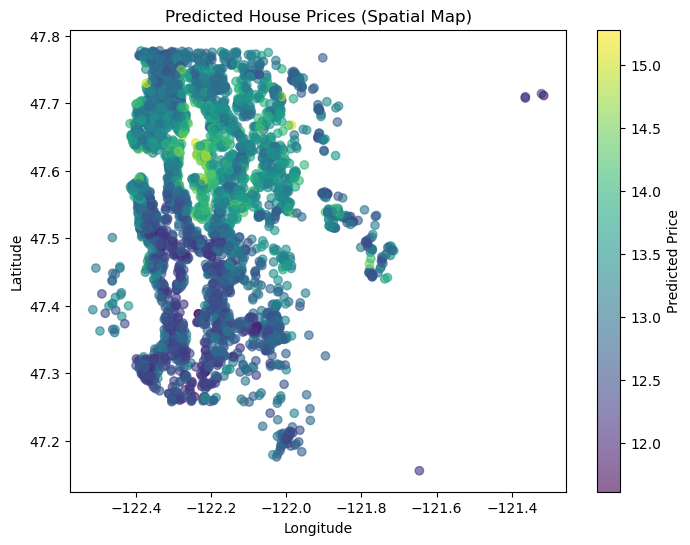

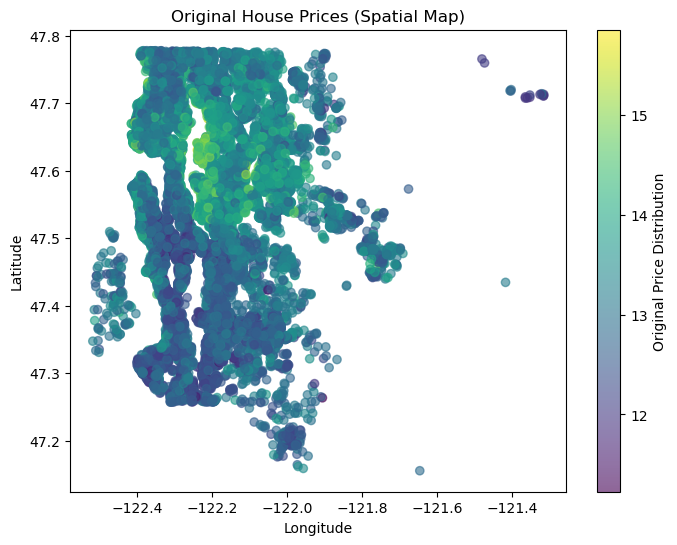

In [342]:
## Best model so far :)
y_test7_pred  = model7_ridge.predict(X_test7_scaled)
plt.figure(figsize=(8,6))
plt.scatter(
    X_test7["long"], 
    X_test7["lat"], 
    c=y_test7_pred, 
    cmap="viridis", 
    alpha=0.6
)
plt.colorbar(label="Predicted Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Predicted House Prices (Spatial Map)")
plt.figure(figsize=(8,6))
plt.scatter(
    df_clean["long"], 
    df_clean["lat"], 
    c=df_clean["price"].apply(lambda x: np.log1p(x)), 
    cmap="viridis", 
    alpha=0.6
)
plt.colorbar(label="Original Price Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Original House Prices (Spatial Map)")
plt.show()

In [358]:
model7_testdata= {
    "y_test7": y_test7,
    "y_test7_pred": y_test7_pred
}
model7_testdata_frame = pd.DataFrame.from_dict(model7_testdata)
model7_testdata_frame.columns = ["Test data","Predicted Test data"]
model7_testdata_frame["Test Price"] = model7_testdata_frame["Test data"].apply(lambda x: 10**x)
model7_testdata_frame["Predicted Price"] = model7_testdata_frame["Predicted Test data"].apply(lambda x: 10**x)
model7_testdata_frame

,Test data,Predicted Test data,Test Price,Predicted Price
735,12.807655,12.868376,6.421779e+12,7.385429e+12
2830,13.670486,13.684137,4.682588e+13,4.832108e+13
4106,13.852807,14.033259,7.125368e+13,1.079590e+14
16218,14.214287,14.229422,1.637900e+14,1.695986e+14
19964,13.474429,13.412121,2.981461e+13,2.582979e+13
...,...,...,...,...
13674,12.730804,12.728572,5.380271e+12,5.352693e+12
20377,13.419502,13.281658,2.627254e+13,1.912748e+13
8805,12.560248,12.644172,3.632854e+12,4.407291e+12
10168,13.312985,13.308097,2.055821e+13,2.032812e+13


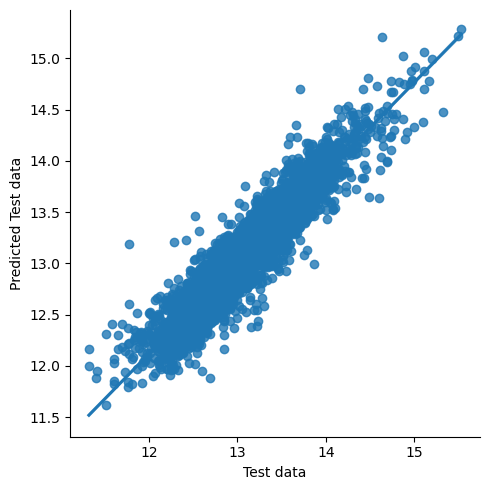

In [ ]:
sns.lmplot(x="Test data",y="Predicted Test data", data=model7_testdata_frame)




## Justifying the use of logscaled values

<Axes: ylabel='sqft_lot'>

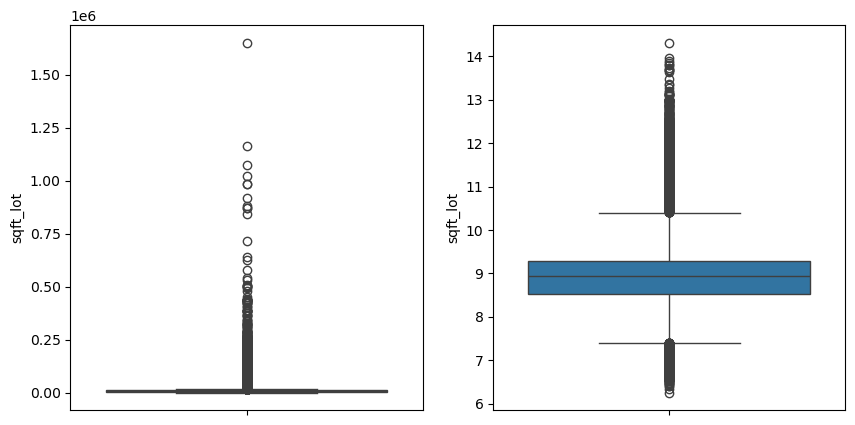

In [104]:
#Handling dispersive behavior
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.boxplot(df_clean["sqft_lot"], ax=ax1)
sns.boxplot(df_clean["sqft_lot"].apply(lambda x: np.log1p(x)), ax=ax2)


<Axes: ylabel='sqft_living'>

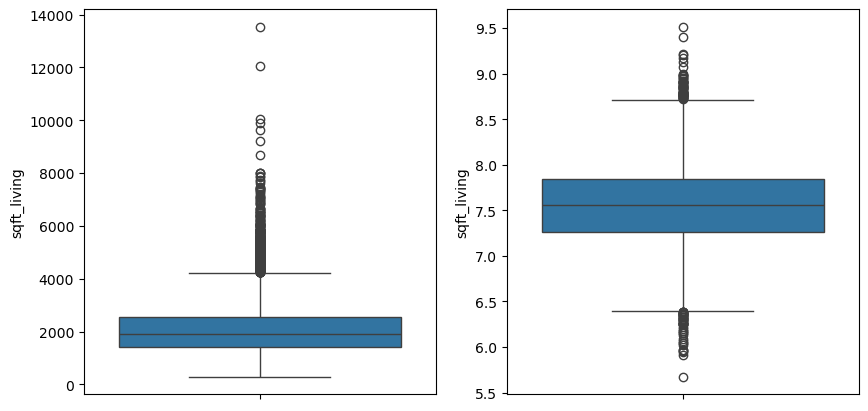

In [105]:
#Handling dispersive behavior
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.boxplot(df_clean["sqft_living"], ax=ax1)
sns.boxplot(df_clean["sqft_living"].apply(lambda x: np.log1p(x)), ax=ax2)

<Axes: xlabel='sqft_lot', ylabel='Count'>

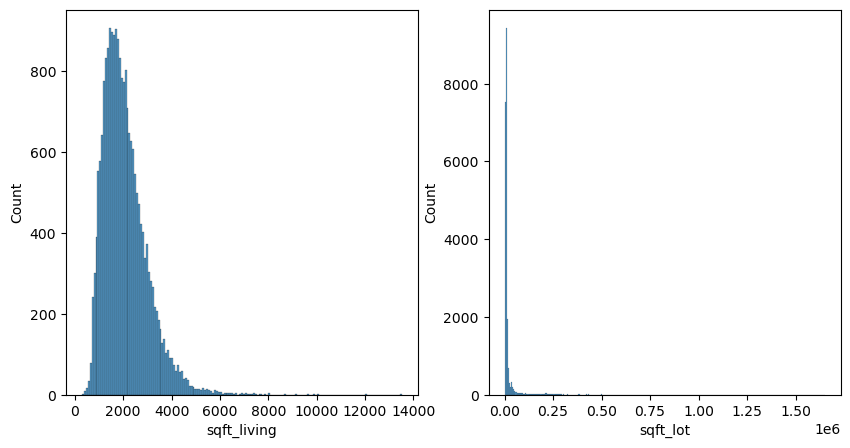

In [106]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.histplot(df_clean["sqft_living"], ax=ax1)
sns.histplot(df_clean["sqft_lot"], ax=ax2)

<Axes: xlabel='sqft_lot', ylabel='Count'>

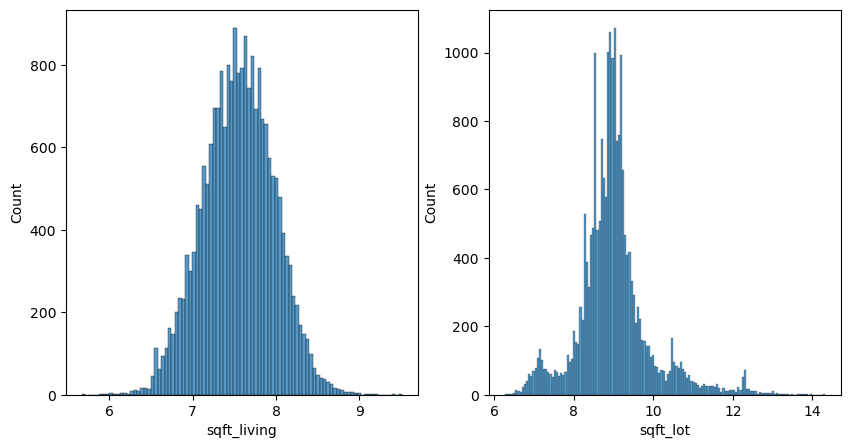

In [107]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.histplot(df_clean["sqft_living"].apply(lambda x: np.log1p(x)), ax=ax1)
sns.histplot(df_clean["sqft_lot"].apply(lambda x: np.log1p(x)), ax=ax2)

<Axes: xlabel='sqft_lot15', ylabel='Count'>

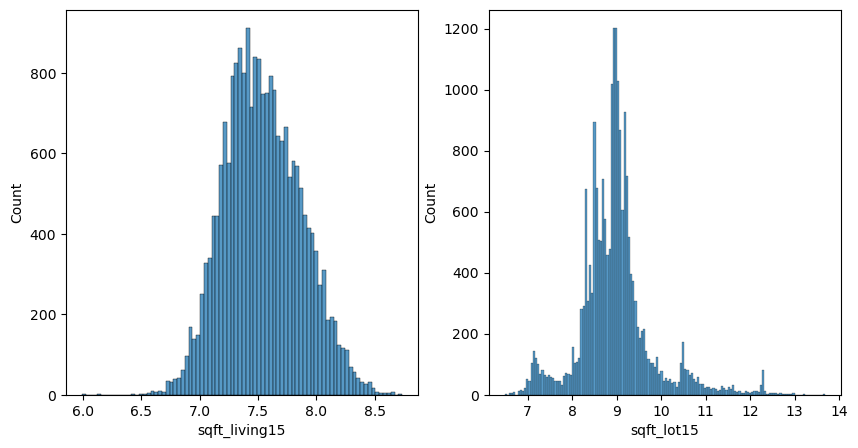

In [108]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.histplot(df_clean["sqft_living15"].apply(lambda x: np.log1p(x)), ax=ax1)
sns.histplot(df_clean["sqft_lot15"].apply(lambda x: np.log1p(x)), ax=ax2)

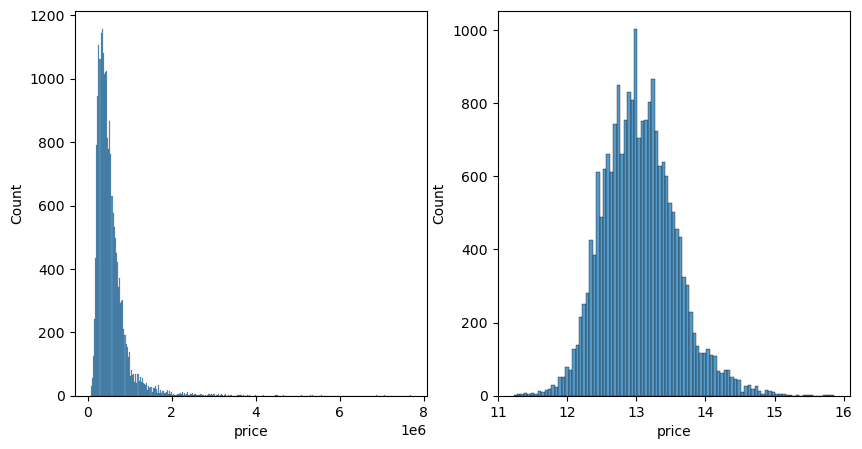

In [247]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize =(10,5))
sns.histplot(df_clean["price"], ax=ax1)
sns.histplot(df_clean["price"].apply(lambda x: np.log1p(x)), ax=ax2)
filepath_targetlog = Path("LR-Exports/Targetlog.png")
plt.savefig(filepath_targetlog)

Suggestion from AI: spatial distribution

In [109]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
coords = poly.fit_transform(feature_select2[["lat", "long"]])
coords = pd.DataFrame(coords)
coords.columns = ["lat","long","lat^2","latxlong","long^2"]